# Robustness of Topological Light–Matter Interaction
## Disorder Effects on Edge LDOS in Nanophotonic SSH Lattices

**Notebook:** 06_disorder_robustness_ldos  

In this notebook, the robustness of edge-enhanced light–matter interaction is
examined by introducing disorder into the nanophotonic SSH lattice. Both
structural and on-site disorder are considered to assess how sensitive the LDOS
enhancement is to imperfections.

The analysis focuses on statistical trends obtained from multiple disorder
realizations, rather than individual configurations. By comparing edge and bulk
LDOS across different disorder strengths, we evaluate whether the enhancement
associated with edge-localized modes persists beyond idealized, fine-tuned
conditions.

This notebook extends the previous LDOS analysis by testing the stability of
the observed effects under realistic perturbations.

## Motivation

In realistic nanophotonic systems, perfect periodicity is never achieved.
Fabrication imperfections and structural variations inevitably introduce
disorder into the lattice.

Since a defining feature of topological physics is robustness against such
perturbations, it is important to test whether the edge-enhanced LDOS observed
earlier persists in the presence of disorder. The analysis therefore focuses on
weak to moderate disorder strengths and emphasizes statistical behavior across
multiple disorder realizations rather than individual configurations.

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [2]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

CONFIG_DIR = Path("..") / "config"

global_config = load_yaml(CONFIG_DIR / "global_config.yaml")
lattice_config = load_yaml(CONFIG_DIR / "lattice_params.yaml")
plotting_config = load_yaml(CONFIG_DIR / "plotting_params.yaml")

NOTEBOOK_KEY = "06_disorder_robustness_ldos"
assert NOTEBOOK_KEY in plotting_config["notebook_figures"]

## Photonic SSH Hamiltonian

The analysis starts from the same finite non-Hermitian SSH lattice Hamiltonian
used in the previous notebook. Using an identical base model ensures that any
changes observed in the LDOS can be attributed directly to the introduction of
disorder, rather than to modifications of the underlying lattice structure.

In [3]:
def build_nonhermitian_ssh_hamiltonian(
    num_cells,
    t1,
    t2,
    gamma_a,
    gamma_b
):
    # Building a real-space non-Hermitian SSH Hamiltonian with open boundaries.
    
    dim = 2 * num_cells
    H = np.zeros((dim, dim), dtype=np.complex128)

    for n in range(num_cells):
        a = 2 * n
        b = 2 * n + 1

        # On-site gain/loss
        H[a, a] = 1j * gamma_a
        H[b, b] = -1j * gamma_b

        # Intra-cell hopping
        H[a, b] = t1
        H[b, a] = t1

        # Inter-cell hopping
        if n < num_cells - 1:
            H[a + 2, b] = t2
            H[b, a + 2] = t2

    return H

## System Parameters

In [4]:
num_cells = lattice_config["lattice"]["num_unit_cells"]
t1 = lattice_config["couplings"]["intra_cell"]
t2 = lattice_config["couplings"]["inter_cell"]

gamma_a = lattice_config["non_hermiticity"]["gain"]["strength"]
gamma_b = lattice_config["non_hermiticity"]["loss"]["strength"]

H = build_nonhermitian_ssh_hamiltonian(num_cells, t1, t2, gamma_a, gamma_b)
W_vals = [0.0, 0.2, 0.5, 0.8]
num_realizations = 20
omega_vals = np.linspace(-3, 3, 600)

## Disorder Model

Disorder is introduced in the form of on-site frequency fluctuations, modeled as
random shifts in the resonator frequencies. This type of disorder captures common
fabrication imperfections while preserving the connectivity of the lattice.

The overall strength of the disorder is controlled by a single parameter \( W \),
which sets the range of the frequency fluctuations applied to each site.

In [5]:
def add_onsite_disorder(H, W):
    dim = H.shape[0]
    disorder = W * (2 * np.random.rand(dim) - 1)
    return H + np.diag(disorder)

## LDOS Definition

We reuse the Green’s-function LDOS formalism from Notebook 05.

In [6]:
def local_density_of_states(H, site, omega, eta=1e-2):
    dim = H.shape[0]
    G = la.inv((omega + 1j * eta) * np.eye(dim) - H)
    return -np.imag(G[site, site]) / np.pi

## Disorder Averaging Strategy

For each chosen disorder strength \( W \), multiple independent disorder
realizations are generated. The LDOS is computed at both edge and bulk sites for
each realization, and the results are then averaged.

This averaging procedure suppresses sample-specific fluctuations and allows
robust trends in the LDOS behavior to be identified as a function of disorder
strength.

## Disorder-Averaged LDOS

In [7]:
ldos_edge_avg = {}
ldos_bulk_avg = {}

# site indices
edge_site = 0
bulk_site = num_cells

for W in W_vals:

    edge_accum = np.zeros_like(omega_vals, dtype=float)
    bulk_accum = np.zeros_like(omega_vals, dtype=float)

    for _ in range(num_realizations):

        # build asymmetric non-Hermitian SSH Hamiltonian
        H0 = build_nonhermitian_ssh_hamiltonian(
            num_cells,
            t1,
            t2,
            gamma_a=gamma_a,
            gamma_b=gamma_b
        )

        # add onsite disorder
        H_dis = add_onsite_disorder(H0, W)

        # accumulate LDOS
        edge_accum += np.array([
            local_density_of_states(H_dis, edge_site, w)
            for w in omega_vals
        ])

        bulk_accum += np.array([
            local_density_of_states(H_dis, bulk_site, w)
            for w in omega_vals
        ])

    # disorder-averaged LDOS
    ldos_edge_avg[W] = edge_accum / num_realizations
    ldos_bulk_avg[W] = bulk_accum / num_realizations


## Robustness of Edge LDOS under Disorder

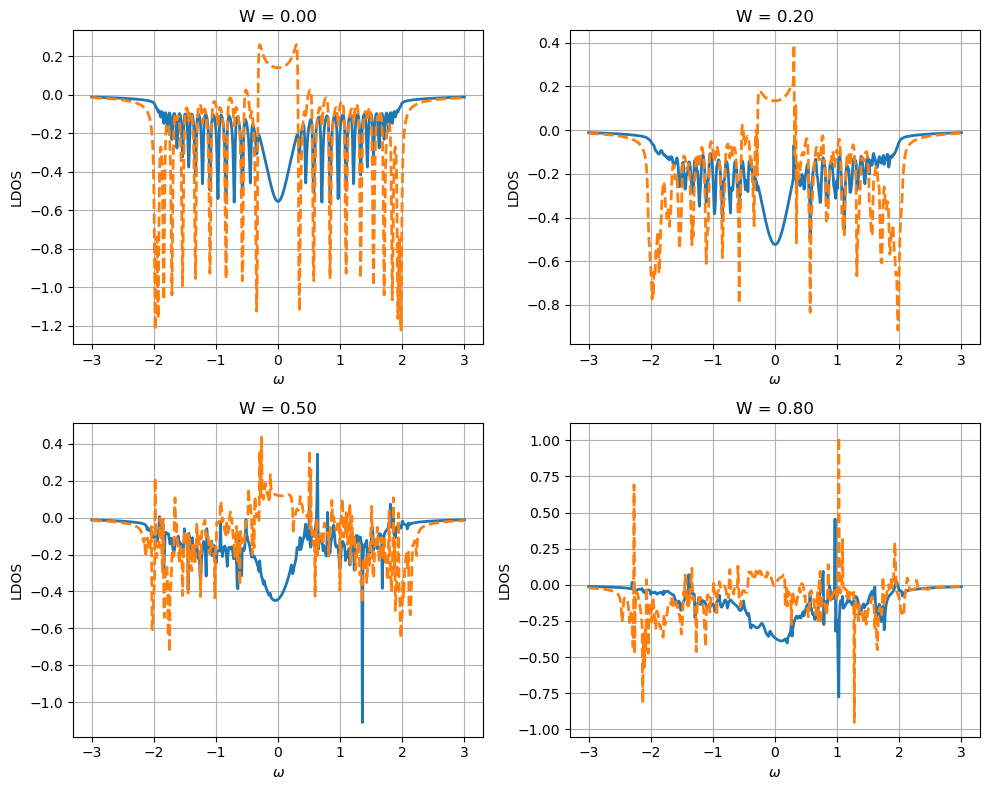

PosixPath('figures/06_disorder_robustness/edge_ldos_disorder.png')

In [8]:
def ensure_directory(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def save_figure(fig, notebook_key, filename, plotting_config):
    cfg = plotting_config["notebook_figures"][notebook_key]
    output_dir = Path(cfg["output_dir"])
    ensure_directory(output_dir)
    path = output_dir / f"{filename}.{plotting_config['global']['figure_format']}"
    fig.savefig(path, dpi=plotting_config["global"]["dpi"], bbox_inches="tight")
    return path

fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.flatten()

for ax, W in zip(axes, W_vals):
    ax.plot(omega_vals, ldos_edge_avg[W], lw=2)
    ax.plot(omega_vals, ldos_bulk_avg[W], "--", lw=2)
    ax.set_title(f"W = {W:.2f}")
    ax.set_xlabel(r"$\omega$")
    ax.set_ylabel("LDOS")
    ax.grid(True)

plt.tight_layout()

plt.show()

fig_path = save_figure(fig, NOTEBOOK_KEY, "edge_ldos_disorder", plotting_config)
fig_path

## Interpretation

The disorder-averaged results show that the LDOS at the edge remains enhanced for
weak to moderate disorder strengths. While increasing disorder leads to a
broadening of spectral features, the enhanced edge response persists over a
finite range of parameters.

At sufficiently strong disorder, the distinction between edge and bulk LDOS
gradually disappears, indicating a breakdown of the conditions required for
topological edge modes. This behavior is consistent with the expectation that
topological features are robust to small perturbations but can be suppressed by
strong disorder.